# TensorFlow/Keras Adversarial Perturbation Optimization

This notebook presents a second adversarial-learning workflow using TensorFlow/Keras. In addition to Gaussian and uniform noise sensitivity, it constructs a trainable perturbation layer whose weights are optimized to make a frozen classifier predict a chosen target class.

The notebook also includes a sign-based perturbation variant and supports both MNIST and CIFAR-10.


## Imports


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    Add,
    Reshape,
    Lambda,
)
from tensorflow.keras.callbacks import (
    Callback,
    ReduceLROnPlateau,
    EarlyStopping,
    ModelCheckpoint,
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import plot_model

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## Select and Load a Dataset


In [2]:
dataset_name = "CIFAR-10"  # "MNIST" or "CIFAR-10"

if dataset_name == "MNIST":
    (x_train, y_train_class), (x_test, y_test_class) = (
        tf.keras.datasets.mnist.load_data()
    )

    x_train = (
        x_train.astype("float32")[..., None]
        / 255.0
    )
    x_test = (
        x_test.astype("float32")[..., None]
        / 255.0
    )

    class_names = [
        str(i)
        for i in range(10)
    ]

else:
    (x_train, y_train_class), (x_test, y_test_class) = (
        tf.keras.datasets.cifar10.load_data()
    )

    x_train = (
        x_train.astype("float32")
        / 255.0
    )
    x_test = (
        x_test.astype("float32")
        / 255.0
    )

    y_train_class = y_train_class.squeeze()
    y_test_class = y_test_class.squeeze()

    class_names = [
        "airplane",
        "car",
        "bird",
        "cat",
        "deer",
        "dog",
        "frog",
        "horse",
        "ship",
        "truck",
    ]

y_train = tf.keras.utils.to_categorical(
    y_train_class,
    10,
)

y_test = tf.keras.utils.to_categorical(
    y_test_class,
    10,
)

print("Dataset:", dataset_name)
print("Training images:", x_train.shape)
print("Test images:", x_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2065s 12us/step
Dataset: CIFAR-10
Training images: (50000, 32, 32, 3)
Test images: (10000, 32, 32, 3)


## Training Callbacks


In [3]:
class TerminateOnBaseline(Callback):
    def __init__(
        self,
        monitor="accuracy",
        baseline=0.9,
    ):
        super().__init__()
        self.monitor = monitor
        self.baseline = baseline

    def on_epoch_end(
        self,
        epoch,
        logs=None,
    ):
        logs = logs or {}
        value = logs.get(
            self.monitor
        )

        if (
            value is not None
            and value >= self.baseline
        ):
            print(
                f"Epoch {epoch + 1}: "
                "reached baseline; "
                "stopping training."
            )
            self.model.stop_training = True


## Classifier Architectures


In [4]:
def cnn_model(
    input_shape,
    conv_units=(32, 64),
    dense_units=(64,),
    dropout_rate=0.5,
):
    model = tf.keras.Sequential(
        name="compact_cnn"
    )

    model.add(
        Input(
            shape=input_shape
        )
    )

    for filters in conv_units:
        model.add(
            Conv2D(
                filters,
                3,
                padding="same",
                activation="relu",
            )
        )
        model.add(
            MaxPooling2D()
        )

    model.add(
        Flatten()
    )

    for units in dense_units:
        model.add(
            Dense(
                units,
                activation="relu",
            )
        )
        model.add(
            Dropout(
                dropout_rate
            )
        )

    model.add(
        Dense(
            10,
            activation="softmax",
        )
    )

    return model


def vgg3(
    input_shape=(32, 32, 3),
):
    model = tf.keras.Sequential(
        [
            Input(shape=input_shape),
            Conv2D(32, 3, padding="same", activation="relu"),
            Conv2D(32, 3, padding="same", activation="relu"),
            MaxPooling2D(),
            Conv2D(64, 3, padding="same", activation="relu"),
            Conv2D(64, 3, padding="same", activation="relu"),
            MaxPooling2D(),
            Conv2D(128, 3, padding="same", activation="relu"),
            Conv2D(128, 3, padding="same", activation="relu"),
            MaxPooling2D(),
            Flatten(),
            Dense(128, activation="relu"),
            Dense(10, activation="softmax"),
        ],
        name="vgg3",
    )

    return model


## Train the Baseline Classifier

The compact CNN works for both selectable datasets. The VGG-style model is retained as an additional CIFAR-10 architecture.


In [5]:
if dataset_name == "CIFAR-10":
    classifier = vgg3(
        input_shape=x_train.shape[1:]
    )
else:
    classifier = cnn_model(
        input_shape=x_train.shape[1:]
    )

classifier.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks = [
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1,
    ),
    EarlyStopping(
        monitor="val_accuracy",
        patience=4,
        restore_best_weights=True,
        verbose=1,
    ),
]

history = classifier.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=256,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1,
)

test_loss, test_accuracy = classifier.evaluate(
    x_test,
    y_test,
    verbose=0,
)

print(
    f"Final test accuracy: "
    f"{test_accuracy:.4f}"
)


Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 17s 50ms/step - accuracy: 0.3648 - loss: 1.7227 - val_accuracy: 0.4910 - val_loss: 1.4009 - learning_rate: 0.0010
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5379 - loss: 1.2786 - val_accuracy: 0.5958 - val_loss: 1.1303 - learning_rate: 0.0010
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6262 - loss: 1.0528 - val_accuracy: 0.6688 - val_loss: 0.9499 - learning_rate: 0.0010
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6812 - loss: 0.9048 - val_accuracy: 0.7052 - val_loss: 0.8556 - learning_rate: 0.0010
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7264 - loss: 0.7865 - val_accuracy: 0.7156 - val_loss: 0.8189 - learning_rate: 0.0010
Epoch 6/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7576 - loss: 0.6959 - val_accuracy: 0.7384 - val_loss: 0.7798 - learning_rate: 0.0010
Epoch 7/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7860 - loss: 0.6182 

# Noise Sensitivity


## Gaussian Noise


Selected example: 7270 class: truck
noise=0.0000, max_abs=0.0000, mse=0.000000, pred=truck, confidence=1.0000
noise=0.0101, max_abs=0.0409, mse=0.000100, pred=truck, confidence=1.0000
noise=0.0202, max_abs=0.0747, mse=0.000402, pred=truck, confidence=1.0000
noise=0.0303, max_abs=0.1036, mse=0.000917, pred=truck, confidence=1.0000
noise=0.0404, max_abs=0.1340, mse=0.001553, pred=truck, confidence=1.0000
noise=0.0505, max_abs=0.1727, mse=0.002429, pred=truck, confidence=1.0000
noise=0.0606, max_abs=0.2714, mse=0.003431, pred=truck, confidence=1.0000
noise=0.0707, max_abs=0.2608, mse=0.004890, pred=truck, confidence=1.0000
noise=0.0808, max_abs=0.3608, mse=0.006089, pred=truck, confidence=0.9985
noise=0.0909, max_abs=0.3309, mse=0.007785, pred=truck, confidence=0.9996
noise=0.1010, max_abs=0.3348, mse=0.009215, pred=truck, confidence=1.0000
noise=0.1111, max_abs=0.4324, mse=0.011336, pred=truck, confidence=0.8332
noise=0.1212, max_abs=0.4802, mse=0.013945, pred=truck, confidence=0.9365
no

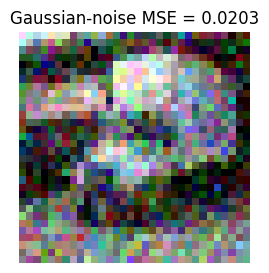

In [6]:
example = np.random.randint(
    len(x_test)
)

image = x_test[example]
actual_class = int(
    y_test_class[example]
)

print(
    "Selected example:",
    example,
    "class:",
    class_names[actual_class],
)

for noise_level in np.linspace(
    0,
    1,
    100,
):
    noisy_image = image + np.random.normal(
        loc=0.0,
        scale=noise_level,
        size=image.shape,
    )

    noisy_image = np.clip(
        noisy_image,
        0.0,
        1.0,
    )

    actual_noise = (
        noisy_image
        - image
    )

    prediction = classifier.predict(
        noisy_image[None, ...],
        verbose=0,
    )[0]

    predicted_class = int(
        np.argmax(
            prediction
        )
    )

    print(
        f"noise={noise_level:.4f}, "
        f"max_abs={np.max(np.abs(actual_noise)):.4f}, "
        f"mse={np.mean(actual_noise ** 2):.6f}, "
        f"pred={class_names[predicted_class]}, "
        f"confidence={np.max(prediction):.4f}"
    )

    if predicted_class != actual_class:
        break

plt.figure(figsize=(3, 3))
plt.imshow(
    noisy_image.squeeze(),
    cmap="gray" if dataset_name == "MNIST" else None,
)
plt.title(
    f"Gaussian-noise MSE = "
    f"{np.mean(actual_noise ** 2):.4f}"
)
plt.axis("off")
plt.show()


## Uniform Noise


Selected example: 7712 class: dog
noise=0.0000, max_abs=0.0000, mse=0.000000, pred=horse, confidence=0.5216


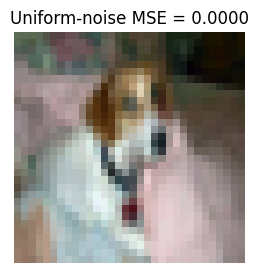

In [7]:
example = np.random.randint(
    len(x_test)
)

image = x_test[example]
actual_class = int(
    y_test_class[example]
)

print(
    "Selected example:",
    example,
    "class:",
    class_names[actual_class],
)

for noise_level in np.linspace(
    0,
    1,
    100,
):
    noisy_image = image + np.random.uniform(
        -noise_level,
        noise_level,
        size=image.shape,
    )

    noisy_image = np.clip(
        noisy_image,
        0.0,
        1.0,
    )

    actual_noise = (
        noisy_image
        - image
    )

    prediction = classifier.predict(
        noisy_image[None, ...],
        verbose=0,
    )[0]

    predicted_class = int(
        np.argmax(
            prediction
        )
    )

    print(
        f"noise={noise_level:.4f}, "
        f"max_abs={np.max(np.abs(actual_noise)):.4f}, "
        f"mse={np.mean(actual_noise ** 2):.6f}, "
        f"pred={class_names[predicted_class]}, "
        f"confidence={np.max(prediction):.4f}"
    )

    if predicted_class != actual_class:
        break

plt.figure(figsize=(3, 3))
plt.imshow(
    noisy_image.squeeze(),
    cmap="gray" if dataset_name == "MNIST" else None,
)
plt.title(
    f"Uniform-noise MSE = "
    f"{np.mean(actual_noise ** 2):.4f}"
)
plt.axis("off")
plt.show()


# Trainable Perturbation Graph


The perturbation can itself be represented as the weights of a Dense layer fed by a constant scalar input. The classifier is frozen so optimization changes only the perturbation.


Model: "perturbation_graph_clipped"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ one (InputLayer)    │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ adversarial_noise   │ (None, 3072)      │      3,072 │ one[0][0]         │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image (InputLayer)  │ (None, 32, 32, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_noise       │ (None, 32, 32, 3) │          0 │ adversarial_nois… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_noise (Add)     │ (None, 32, 32, 3) │          0 │ image[0][0],      │
│                     │                   │            │ reshape_noise[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clip (Lambda)       │ (None, 32, 32, 3) │          0 │ add_noise[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg3 (Sequential)   │ (None, 10)        │    550,570 │ clip[0][0]        │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 553,642 (2.11 MB)

 Trainable params: 3,072 (12.00 KB)

 Non-trainable params: 550,570 (2.10 MB)

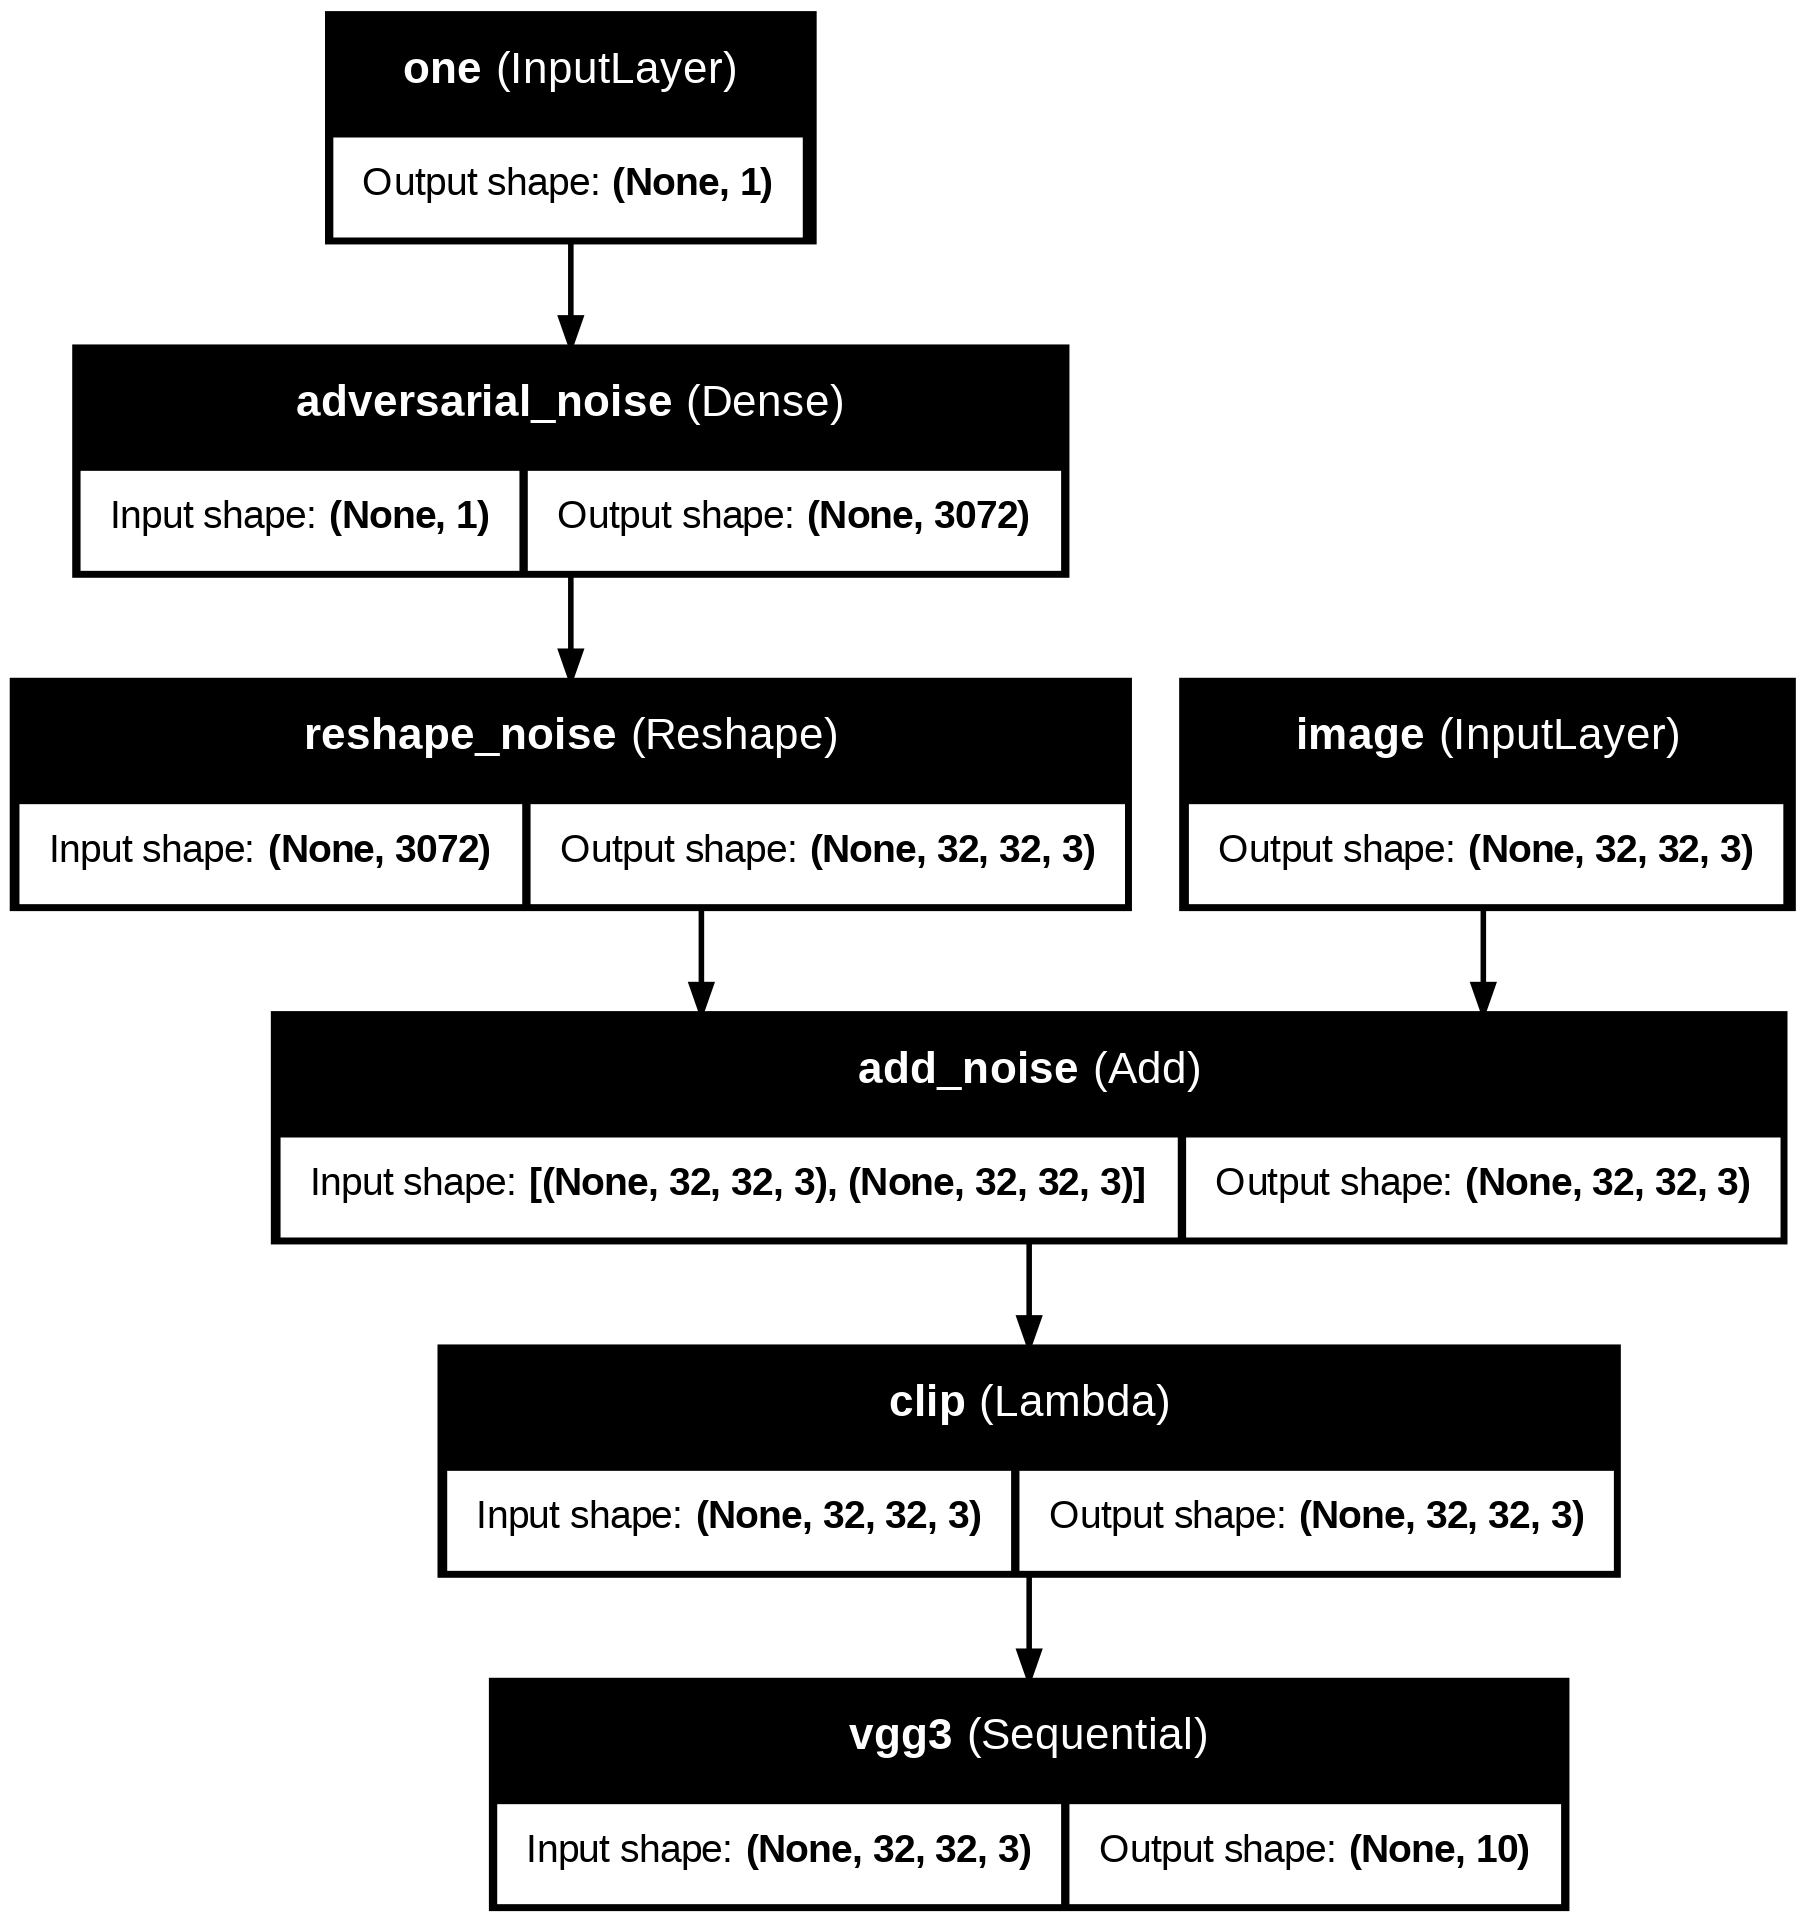

In [10]:
def build_perturbation_graph(
    trained_model,
    image_shape,
    use_clip=True,
    regularization=None,
):
    original_trainable = (
        trained_model.trainable
    )
    trained_model.trainable = False

    image_input = Input(
        shape=image_shape,
        name="image",
    )

    one_input = Input(
        shape=(1,),
        name="one",
    )

    perturbation = Dense(
        int(np.prod(image_shape)),
        activation=None,
        use_bias=False,
        kernel_initializer="zeros",
        kernel_regularizer=regularization,
        name="adversarial_noise",
    )(one_input)

    perturbation = Reshape(
        image_shape,
        name="reshape_noise",
    )(perturbation)

    perturbed = Add(
        name="add_noise"
    )(
        [
            image_input,
            perturbation,
        ]
    )

    if use_clip:
        perturbed = Lambda(
            lambda x: tf.clip_by_value(
                x,
                0.0,
                1.0,
            ),
            name="clip",
        )(perturbed)

    output = trained_model(
        perturbed,
        training=False,
    )

    adversarial_model = Model(
        inputs=[
            image_input,
            one_input,
        ],
        outputs=output,
        name=(
            "perturbation_graph_clipped"
            if use_clip
            else "perturbation_graph_unclipped"
        ),
    )

    # Restore only after graph construction.
    # The nested call remains non-trainable in this attack model.
    trained_model.trainable = original_trainable

    return adversarial_model


graph_without_clip = build_perturbation_graph(
    classifier,
    x_train.shape[1:],
    use_clip=False,
)

graph_with_clip = build_perturbation_graph(
    classifier,
    x_train.shape[1:],
    use_clip=True,
)

graph_with_clip.summary()

plot_model(
    graph_with_clip,
    show_shapes=True,
    show_layer_names=True,
)

## Optimized Targeted Perturbation

A target class is chosen and the perturbation weights are optimized with the classifier frozen. An L2 regularizer can be applied to encourage smaller perturbations.


In [12]:
def generate_adversarial(
    input_image,
    trained_model,
    target_class,
    regularization=l2(0.0),
    learning_rate=0.005,
    epochs=2000,
):
    original_trainable = (
        trained_model.trainable
    )
    trained_model.trainable = False

    image_input = Input(
        shape=input_image.shape,
        name="image",
    )

    one_input = Input(
        shape=(1,),
        name="one",
    )

    perturbation = Dense(
        int(np.prod(input_image.shape)),
        activation=None,
        use_bias=False,
        kernel_initializer="zeros",
        kernel_regularizer=regularization,
        name="adversarial_noise",
    )(one_input)

    perturbation = Reshape(
        input_image.shape,
        name="reshape_noise",
    )(perturbation)

    perturbed = Add(
        name="add_noise"
    )(
        [
            image_input,
            perturbation,
        ]
    )

    perturbed = Lambda(
        lambda x: tf.clip_by_value(
            x,
            0.0,
            1.0,
        ),
        name="clip",
    )(perturbed)

    output = trained_model(
        perturbed,
        training=False,
    )

    attack_model = Model(
        inputs=[
            image_input,
            one_input,
        ],
        outputs=output,
    )

    attack_model.compile(
        optimizer=tf.keras.optimizers.SGD(
            learning_rate=learning_rate
        ),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    target_vector = np.zeros(
        (1, 10),
        dtype="float32",
    )
    target_vector[
        0,
        int(target_class),
    ] = 1.0

    attack_model.fit(
        {
            "image": input_image[None, ...],
            "one": np.ones(
                (1, 1),
                dtype="float32",
            ),
        },
        target_vector,
        epochs=epochs,
        verbose=0,
        callbacks=[
            TerminateOnBaseline(
                monitor="accuracy",
                baseline=1.0,
            )
        ],
    )

    dense_noise = attack_model.get_layer(
        "adversarial_noise"
    ).get_weights()[0]

    noise = dense_noise.reshape(
        input_image.shape
    )

    adversarial_image = np.clip(
        input_image + noise,
        0.0,
        1.0,
    )

    trained_model.trainable = (
        original_trainable
    )

    return adversarial_image

## Generate an Optimized Adversarial Example


Actual class: truck
Second-most-likely target: airplane
Least-likely target: deer
Epoch 3: reached baseline; stopping training.
Predicted adversarial class: airplane
Confidence: 0.9014676213264465
Maximum absolute perturbation: 0.03396078944206238
Mean squared perturbation: 4.2104486055905e-05


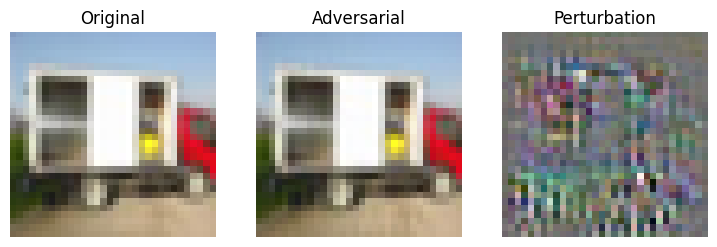

In [13]:
while True:
    example = np.random.randint(
        len(x_test)
    )

    image = x_test[example]

    clean_prediction = classifier.predict(
        image[None, ...],
        verbose=0,
    )[0]

    if (
        np.argmax(clean_prediction)
        == int(y_test_class[example])
    ):
        break

actual_class = int(
    y_test_class[example]
)

second_most_likely = int(
    np.argsort(
        clean_prediction
    )[-2]
)

least_likely = int(
    np.argsort(
        clean_prediction
    )[0]
)

print(
    "Actual class:",
    class_names[actual_class],
)
print(
    "Second-most-likely target:",
    class_names[second_most_likely],
)
print(
    "Least-likely target:",
    class_names[least_likely],
)

# Preserve both target-selection ideas.
target_class = second_most_likely
# target_class = least_likely

adversarial_image = generate_adversarial(
    image,
    classifier,
    target_class=target_class,
    regularization=l2(0.0),
)

perturbation = (
    adversarial_image
    - image
)

adv_prediction = classifier.predict(
    adversarial_image[None, ...],
    verbose=0,
)[0]

print(
    "Predicted adversarial class:",
    class_names[
        int(np.argmax(adv_prediction))
    ],
)
print(
    "Confidence:",
    float(
        np.max(adv_prediction)
    ),
)
print(
    "Maximum absolute perturbation:",
    float(
        np.max(
            np.abs(
                perturbation
            )
        )
    ),
)
print(
    "Mean squared perturbation:",
    float(
        np.mean(
            perturbation ** 2
        )
    ),
)

fig, ax = plt.subplots(
    1,
    3,
    figsize=(9, 3),
)

ax[0].imshow(
    image.squeeze(),
    cmap="gray" if dataset_name == "MNIST" else None,
)
ax[0].set_title(
    "Original"
)
ax[0].axis("off")

ax[1].imshow(
    adversarial_image.squeeze(),
    cmap="gray" if dataset_name == "MNIST" else None,
)
ax[1].set_title(
    "Adversarial"
)
ax[1].axis("off")

display_noise = perturbation

if dataset_name == "MNIST":
    ax[2].imshow(
        display_noise.squeeze(),
        cmap="gray",
    )
else:
    scaled_noise = (
        display_noise
        - display_noise.min()
    )

    denominator = (
        scaled_noise.max()
        + 1e-8
    )

    ax[2].imshow(
        scaled_noise
        / denominator
    )

ax[2].set_title(
    "Perturbation"
)
ax[2].axis("off")

plt.show()


# Sign-Based Perturbation Direction


In [15]:
def generate_adversarial_with_sign(
    input_image,
    trained_model,
    target_class,
    step=0.01,
):
    original_trainable = (
        trained_model.trainable
    )
    trained_model.trainable = False

    image_input = Input(
        shape=input_image.shape,
        name="image",
    )

    one_input = Input(
        shape=(1,),
        name="one",
    )

    perturbation = Dense(
        int(np.prod(input_image.shape)),
        activation=None,
        use_bias=False,
        kernel_initializer="zeros",
        name="adversarial_noise",
    )(one_input)

    perturbation = Reshape(
        input_image.shape
    )(perturbation)

    perturbed = Lambda(
        lambda tensors: tf.clip_by_value(
            tensors[0] + tensors[1],
            0.0,
            1.0,
        )
    )(
        [
            image_input,
            perturbation,
        ]
    )

    output = trained_model(
        perturbed,
        training=False,
    )

    attack_model = Model(
        inputs=[
            image_input,
            one_input,
        ],
        outputs=output,
    )

    attack_model.compile(
        optimizer=tf.keras.optimizers.SGD(
            learning_rate=0.001
        ),
        loss="categorical_crossentropy",
    )

    target_vector = np.zeros(
        (1, 10),
        dtype="float32",
    )
    target_vector[
        0,
        int(target_class),
    ] = 1.0

    attack_model.fit(
        {
            "image": input_image[None, ...],
            "one": np.ones(
                (1, 1),
                dtype="float32",
            ),
        },
        target_vector,
        epochs=1,
        verbose=0,
    )

    weight = attack_model.get_layer(
        "adversarial_noise"
    ).get_weights()[0]

    direction = np.sign(
        weight
    ).reshape(
        input_image.shape
    )

    original_prediction = (
        trained_model.predict(
            input_image[None, ...],
            verbose=0,
        )[0]
    )

    original_class = int(
        np.argmax(
            original_prediction
        )
    )

    noise_level = step

    while noise_level < 1.0:
        adversarial_image = np.clip(
            input_image
            + direction * noise_level,
            0.0,
            1.0,
        )

        prediction = trained_model.predict(
            adversarial_image[None, ...],
            verbose=0,
        )[0]

        if (
            np.argmax(prediction)
            != original_class
        ):
            break

        noise_level += step

    trained_model.trainable = (
        original_trainable
    )

    return (
        adversarial_image,
        noise_level,
    )

sign_adversarial_image, sign_noise_level = (
    generate_adversarial_with_sign(
        image,
        classifier,
        target_class=target_class,
    )
)

sign_prediction = classifier.predict(
    sign_adversarial_image[None, ...],
    verbose=0,
)[0]

print(
    "Sign-based perturbation level:",
    sign_noise_level,
)
print(
    "Resulting prediction:",
    class_names[
        int(
            np.argmax(
                sign_prediction
            )
        )
    ],
)

Sign-based perturbation level: 0.01
Resulting prediction: airplane


## Key Takeaways

The TensorFlow/Keras workflow demonstrates a different way to construct adversarial examples: the perturbation itself is represented as trainable model parameters while the classifier remains fixed. The Gaussian and uniform experiments provide non-adaptive baselines, the optimized perturbation directly targets a desired class, and the sign-based variant converts the learned direction into a simple signed perturbation.
